# EE 446 TinyML — Model Pruning with Quantization  
## Student TODO Version: Pruning and Quantization of a DNN Using the UCI Human Activity Recognition Dataset

### Overview
In this notebook, you will:
- train a baseline DNN on the **UCI HAR** dataset,
- apply **magnitude-based pruning**,
- compare the pruned model before and after `strip_pruning(...)`, and
- combine pruning with **float16 quantization**.

Use the **`Python (tinyml-arduino)`** Jupyter kernel for this notebook.


## 1. Environment Setup

This notebook is designed to run with the **`Python (tinyml-arduino)`** Jupyter kernel that you already created.

This notebook assumes the environment already contains:
- `tensorflow==2.14.1`
- `tensorflow-model-optimization==0.8.0`
- `numpy`, `pandas`, `matplotlib`, and `scikit-learn`

Do **not** reinstall TensorFlow packages inside the notebook if you are already using the working TinyML environment.


In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

!pip install -q tensorflow-model-optimization tf-keras

import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot
import tf_keras
from pathlib import Path
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import tf_keras as keras
from tf_keras import layers


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)
print("Keras version:", tf_keras.__version__)

Python executable: /usr/bin/python3
TensorFlow version: 2.20.0
TF-MOT version: 0.8.0
Keras version: 2.20.0


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.

The code below downloads and extracts the dataset if it is not already present in the working directory.


In [2]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset downloaded and extracted.


## 3. Load the Data

In [3]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32
    # 5. Convert labels to zero-based class indices by subtracting 1

    # <-- Enter your code here <--#

    root_dir = Path(root_dir)

    # Now the / operator will work correctly
    X_train = np.loadtxt(root_dir / "train" / "X_train.txt", dtype=np.float32)
    y_train = np.loadtxt(root_dir / "train" / "y_train.txt", dtype=np.int32) - 1

    X_test = np.loadtxt(root_dir / "test" / "X_test.txt", dtype=np.float32)
    y_test = np.loadtxt(root_dir / "test" / "y_test.txt", dtype=np.int32) - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO:
# Define num_features and num_classes.
# Print the train/test shapes and the number of features/classes.

# <-- Enter your code here <--#
num_features = X_train.shape[1]
num_classes = len(class_names)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Number of features: {num_features}")
print(f"Number of classes: {num_classes}")


X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape: (2947, 561)
y_test shape: (2947,)
Number of features: 561
Number of classes: 6


## 4. Quick Inspection

In [4]:
# TODO:
# Create a small summary table showing:
# - class index,
# - class name, and
# - number of training samples in each class.

# <-- Enter your code here <--#
class_counts = np.bincount(y_train, minlength=len(class_names))

class_summary = pd.DataFrame({
    "Class Index": np.arange(len(class_names)),
    "Class Name": class_names,
    "Training Samples": class_counts
})

class_summary

,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [5]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    # <-- Enter your code here <--#
    model = keras.Sequential([
        keras.layers.Dense(256, activation="relu", input_shape=(input_dim,)),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model
baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model

In [6]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#

baseline_history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
92/92 [==============================] - 10s 37ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 2s 22ms/step - loss: 0.1638 - accuracy: 0.9376 - val_loss: 0.1396 - val_accuracy: 0.9375
Epoch 3/40
92/92 [==============================] - 2s 25ms/step - loss: 0.1143 - accuracy: 0.9573 - val_loss: 0.2379 - val_accuracy: 0.9205
Epoch 4/40
92/92 [==============================] - 4s 41ms/step - loss: 0.0888 - accuracy: 0.9636 - val_loss: 0.1414 - val_accuracy: 0.9436
Epoch 5/40
92/92 [==============================] - 3s 28ms/step - loss: 0.0877 - accuracy: 0.9667 - val_loss: 0.1866 - val_accuracy: 0.9279
Epoch 6/40
92/92 [==============================] - 2s 22ms/step - loss: 0.0743 - accuracy: 0.9697 - val_loss: 0.1920 - val_accuracy: 0.9341
Epoch 7/40
92/92 [==============================] - 2s 24ms/step - loss: 0.0571 - accuracy: 0.9791 - val_loss: 0.1407 - val_accuracy: 0.9443
Epoch 8/40
9

### Training Curves

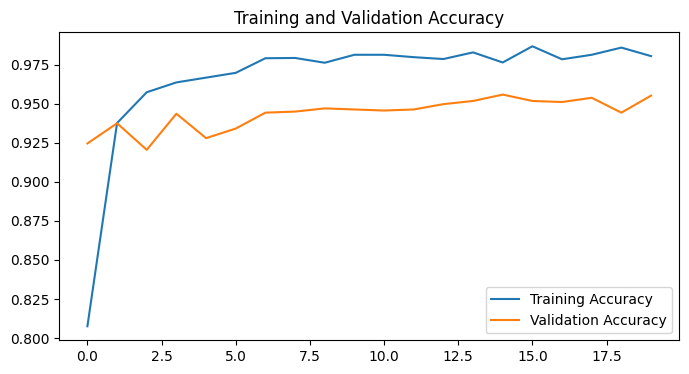

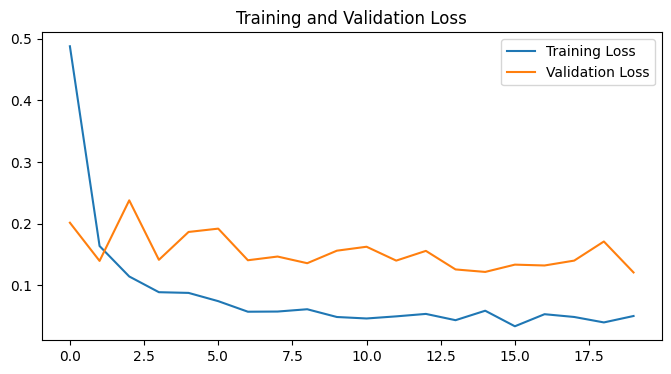

In [7]:
# TODO:
# Plot:
# 1. training accuracy vs validation accuracy
# 2. training loss vs validation loss

# <-- Enter your code here <--#
acc = baseline_history.history['accuracy']
val_acc = baseline_history.history['val_accuracy']
loss = baseline_history.history['loss']
val_loss = baseline_history.history['val_loss']
epochs_range = range(len(acc))

# 1. Plot training vs. validation accuracy
plt.figure(figsize=(8, 4))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.show()

# 2. Plot training vs. validation loss
plt.figure(figsize=(8, 4))
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## 6. Evaluate the Baseline Keras Model

93/93 [==============================] - 0s 2ms/step
Test Accuracy: 0.9386
Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.94      0.97      0.95       496
  WALKING_UPSTAIRS       0.95      0.92      0.94       471
WALKING_DOWNSTAIRS       0.95      0.94      0.94       420
           SITTING       0.95      0.87      0.91       491
          STANDING       0.86      0.96      0.91       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



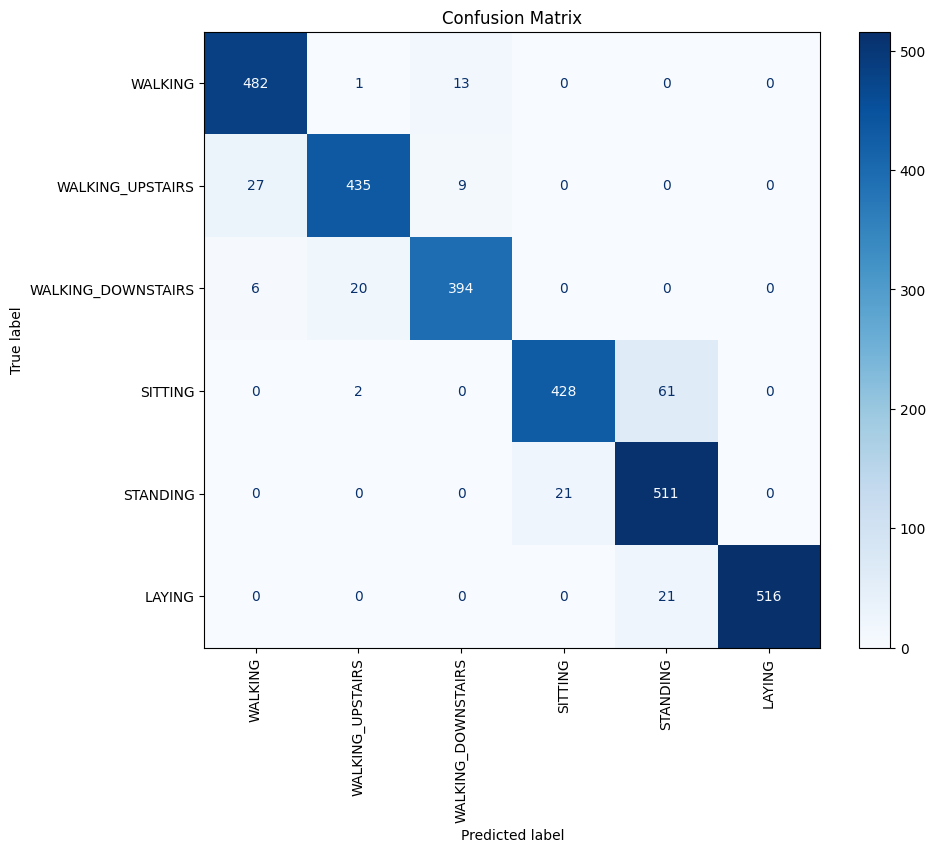

In [8]:
# TODO:
# 1. Predict class probabilities on X_test
# 2. Convert probabilities to class labels using argmax
# 3. Compute the test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#
y_pred_probs = baseline_model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

# Part I: Model Pruning with Sparsity

In this part, we apply **magnitude-based pruning** to the DNN. The key idea is to gradually set small-magnitude weights to zero during training.

We will compare:
1. the baseline TensorFlow Lite model,
2. the pruned model converted **without** stripping the pruning wrappers, and
3. the stripped sparse model converted with **experimental sparsity-aware optimization**.


## 7. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model size.


In [9]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the TFLite input tensor expects int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        # <-- Enter your code here <--#

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()


        # TODO:
        # Dequantize the output only when the output tensor is int8 or uint8.

        # <-- Enter your code here <--#

        output = interpreter.get_tensor(output_details["index"])
        y_pred.append(np.argmax(output, axis=1)[0])

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    # TODO:
    # Create a TFLiteConverter from the Keras model and return the converted FP32 model bytes.
    # <-- Enter your code here <--#
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

## 8. Convert the Baseline Model to TensorFlow Lite

In [10]:
# TODO:
# Convert the baseline model to FP32 TensorFlow Lite.
# Save the .tflite file, compute its size in KB, and evaluate it on X_test.
converter = tf.lite.TFLiteConverter.from_keras_model(baseline_model)

# Convert to FP32 TFLite format
baseline_tflite = converter.convert()

# Save the model and get size in KB
baseline_tflite_size_kb = save_binary_model(baseline_tflite, "baseline_model_fp32.tflite")

# Evaluate on X_test
baseline_tflite_acc, baseline_tflite_preds = evaluate_tflite_model(baseline_tflite, X_test, y_test)

# Print results
print(f"Baseline TFLite FP32 Accuracy: {baseline_tflite_acc:.4f}")
print(f"Baseline TFLite FP32 Size (KB): {baseline_tflite_size_kb:.2f}")

Baseline TFLite FP32 Accuracy: 0.9386
Baseline TFLite FP32 Size (KB): 726.63


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## 9. Apply Magnitude-Based Pruning

We will prune the DNN using a **polynomial decay schedule**:
- start from low sparsity,
- gradually increase sparsity during training, and
- finish with a highly sparse model.

After training, we will compare:
- the pruned model **with** the pruning wrappers still present, and
- the final sparse model after applying `strip_pruning(...)`.


In [11]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

# TODO:
# Compute steps_per_epoch using 80% of the training set and the selected batch size.
# Define pruning_params using PolynomialDecay with:
# - initial_sparsity=0.20
# - final_sparsity=0.85
# - begin_step=0
# - end_step=steps_per_epoch * pruning_epochs

# <-- Enter your code here <--#
steps_per_epoch = np.ceil((X_train.shape[0] * 0.8) / batch_size).astype(np.int32)

pruning_params = {
    'pruning_schedule': PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs
    )
}
# TODO:
# Create the pruned model by wrapping a fresh baseline DNN with prune_low_magnitude.
# Compile it with Adam(1e-3), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#


# Compile it with Adam(1e-3), sparse_categorical_crossentropy, and accuracy.
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

# TODO:
# Compute steps_per_epoch using 80% of the training set and the selected batch size.
# Define pruning_params using PolynomialDecay with:
# - initial_sparsity=0.20
# - final_sparsity=0.85
# - begin_step=0
# - end_step=steps_per_epoch * pruning_epochs

# <-- Enter your code here <--#
steps_per_epoch = np.ceil((X_train.shape[0] * 0.8) / batch_size).astype(np.int32)

pruning_params = {
    'pruning_schedule': PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs
    )
}
# TODO:
# Create the pruned model by wrapping a fresh baseline DNN with prune_low_magnitude.
# Compile it with Adam(1e-3), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#


# Compile it with Adam(1e-3), sparse_categorical_crossentropy, and accuracy.
model = build_baseline_model(input_dim=X_train.shape[1], num_classes=len(np.unique(y_train)))
model.build(input_shape=(None, X_train.shape[1]))

pruned_model = prune_low_magnitude(model, **pruning_params)

pruned_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the pruned model using:
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks

# <-- Enter your code here <--#
history = pruned_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks
)


pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the pruned model using:
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks

# <-- Enter your code here <--#
history = pruned_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks
)

Epoch 1/12
92/92 [==============================] - 4s 16ms/step - loss: 0.4751 - accuracy: 0.8067 - val_loss: 0.2226 - val_accuracy: 0.9218
Epoch 2/12
92/92 [==============================] - 1s 14ms/step - loss: 0.1663 - accuracy: 0.9367 - val_loss: 0.1592 - val_accuracy: 0.9293
Epoch 3/12
92/92 [==============================] - 1s 8ms/step - loss: 0.1311 - accuracy: 0.9498 - val_loss: 0.2181 - val_accuracy: 0.9279
Epoch 4/12
92/92 [==============================] - 1s 8ms/step - loss: 0.0919 - accuracy: 0.9691 - val_loss: 0.1689 - val_accuracy: 0.9320
Epoch 5/12
92/92 [==============================] - 1s 8ms/step - loss: 0.1259 - accuracy: 0.9515 - val_loss: 0.1484 - val_accuracy: 0.9395
Epoch 6/12
92/92 [==============================] - 1s 8ms/step - loss: 0.1224 - accuracy: 0.9577 - val_loss: 0.1762 - val_accuracy: 0.9354
Epoch 7/12
92/92 [==============================] - 1s 8ms/step - loss: 0.2871 - accuracy: 0.9294 - val_loss: 0.1576 - val_accuracy: 0.9388
Epoch 8/12
92/92 [

## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers

First, we convert the pruned model **with** the pruning wrappers still attached.

Next, we strip the pruning wrappers and convert the resulting sparse model with:
- `tf.lite.Optimize.EXPERIMENTAL_SPARSITY`

This is the proper way to preserve sparsity in the exported TensorFlow Lite model.


In [12]:
# TODO:
# 1. Convert the pruned model WITH the pruning wrappers still attached to FP32 TensorFlow Lite.
# 2. Save the model and evaluate it on X_test.
# 3. Strip the pruning wrappers using strip_pruning(...).
# 4. Convert the stripped model with tf.lite.Optimize.EXPERIMENTAL_SPARSITY.
# 5. Save the stripped sparse model and evaluate it on X_test.

# <-- Enter your code here <--#

converter = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
tflite_pruned_model = converter.convert()
size_pruned_kb = save_binary_model(tflite_pruned_model, "pruned_model_wrappers.tflite")

acc_pruned, _ = evaluate_tflite_model(tflite_pruned_model, X_test, y_test)

stripped_model = strip_pruning(pruned_model)

converter_sparse = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter_sparse.optimizations = [tf.lite.Optimize.DEFAULT]
converter_sparse.target_spec.supported_types = [tf.float16]

converter_sparse.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
tflite_sparse_model = converter_sparse.convert()

size_sparse_kb = save_binary_model(tflite_sparse_model, "stripped_sparse_model.tflite")
acc_sparse, _ = evaluate_tflite_model(tflite_sparse_model, X_test, y_test)

print(f"Pruned (Wrappers) Accuracy: {acc_pruned:.4f}, Size: {size_pruned_kb:.2f} KB")
print(f"Stripped Sparse Accuracy: {acc_sparse:.4f}, Size: {size_sparse_kb:.2f} KB")


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Pruned (Wrappers) Accuracy: 0.9287, Size: 1453.80 KB
Stripped Sparse Accuracy: 0.9287, Size: 162.94 KB


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## 11. Part I Comparison: Accuracy and Model Size

In [13]:
# TODO:
# Create a comparison DataFrame for Part I with the columns:
# Model, Format, Test Accuracy, Model Size (KB)

# Include:
# - baseline FP32 TFLite
# - pruned FP32 TFLite with mask
# - stripped sparse FP32 TFLite

# <-- Enter your code here <--#
part1_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Pruned",
        "Stripped Sparse"
    ],
    "Format": [
        "FP32 TFLite",
        "FP32 TFLite with mask",
        "Sparse FP32 TFLite"
    ],
    "Test Accuracy": [
        baseline_tflite_acc,
        acc_pruned,
        acc_sparse
    ],
    "Model Size (KB)": [
        baseline_tflite_size_kb,
        size_pruned_kb,
        size_sparse_kb
    ]
})

part1_comparison

,Model,Format,Test Accuracy,Model Size (KB)
0,Baseline,FP32 TFLite,0.938582,726.628906
1,Pruned,FP32 TFLite with mask,0.928741,1453.800781
2,Stripped Sparse,Sparse FP32 TFLite,0.928741,162.941406


In [ ]:
# TODO:
# Plot:
# 1. a bar chart of the Part I model sizes
# 2. a bar chart of the Part I test accuracies

# <-- Enter your code here <--#


### Confusion Matrix for the Stripped Sparse Model

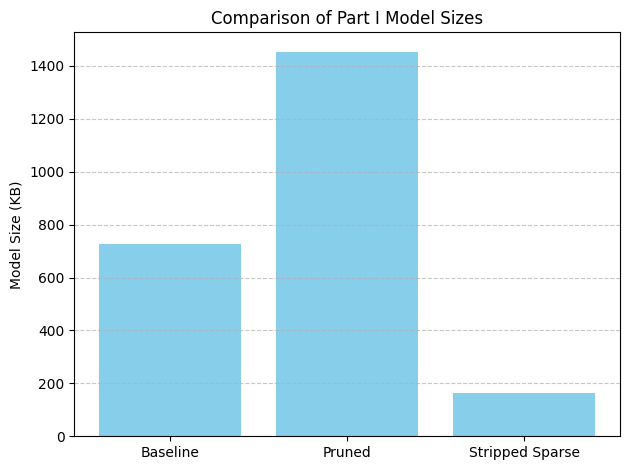

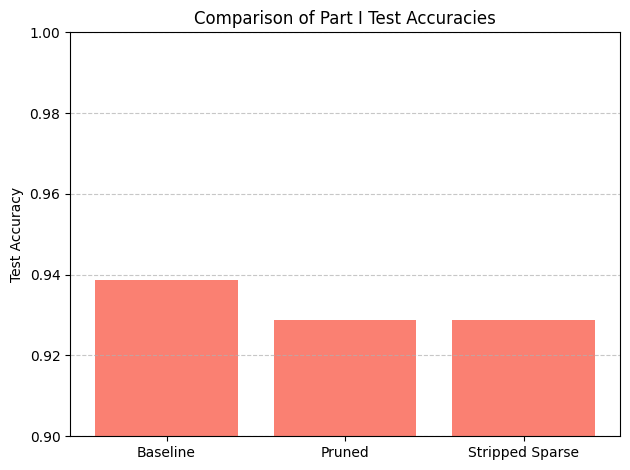

In [14]:
# TODO:
# Plot the confusion matrix for the stripped sparse TFLite model.
# Print the classification report for the stripped sparse TFLite model.

# <-- Enter your code here <--#
import matplotlib.pyplot as plt

models = ["Baseline", "Pruned", "Stripped Sparse"]
accuracies = [baseline_tflite_acc, acc_pruned, acc_sparse]
sizes = [baseline_tflite_size_kb, size_pruned_kb, size_sparse_kb]

plt.bar(models, sizes, color='skyblue')
plt.ylabel('Model Size (KB)')
plt.title('Comparison of Part I Model Sizes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.bar(models, accuracies, color='salmon')
plt.ylabel('Test Accuracy')
plt.title('Comparison of Part I Test Accuracies')
plt.ylim(0.9, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Part II: Model Pruning + Float16 Quantization

In this part, we combine **pruning** and **float16 quantization**.

We will compare:
1. the pruned TensorFlow Lite model **with** the pruning wrappers still attached, after float16 quantization, and
2. the stripped sparse TensorFlow Lite model after **both** sparsity-aware optimization and float16 quantization.

This lets us observe whether properly finalizing the pruned model leads to a more compact deployable representation.


In [15]:
# TODO:
# Part II: combine pruning and float16 quantization.
#
# 1. Convert the pruned model with mask using:
#    - optimizations = [tf.lite.Optimize.DEFAULT]
#    - supported_types = [tf.float16]
# 2. Save and evaluate the float16 model with mask.
# 3. Convert the stripped sparse model using:
#    - optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
#    - supported_types = [tf.float16]
# 4. Save and evaluate the stripped sparse + float16 model.

# <-- Enter your code here <--#

# 1. Convert the pruned model with mask
converter_f16 = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
converter_f16.optimizations = [tf.lite.Optimize.DEFAULT]
converter_f16.target_spec.supported_types = [tf.float16]
tflite_pruned_f16 = converter_f16.convert()

# 2. Save and evaluate the float16 model with mask
size_pruned_f16_kb = save_binary_model(tflite_pruned_f16, "pruned_model_f16.tflite")
acc_pruned_f16, _ = evaluate_tflite_model(tflite_pruned_f16, X_test, y_test)

# 3. Convert the stripped sparse model
# Ensure the model is stripped of pruning wrappers first
stripped_model = strip_pruning(pruned_model)

# 4. Convert stripped model with EXPERIMENTAL_SPARSITY and float16
converter_sparse_f16 = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter_sparse_f16.optimizations = [
    tf.lite.Optimize.DEFAULT,
    tf.lite.Optimize.EXPERIMENTAL_SPARSITY
]
converter_sparse_f16.target_spec.supported_types = [tf.float16]
tflite_sparse_f16 = converter_sparse_f16.convert()

# 5. Save and evaluate the stripped sparse + float16 model
size_sparse_f16_kb = save_binary_model(tflite_sparse_f16, "stripped_sparse_f16.tflite")
acc_sparse_f16, _ = evaluate_tflite_model(tflite_sparse_f16, X_test, y_test)

print(f"Pruned (Mask) Float16 Accuracy: {acc_pruned_f16:.4f}, Size: {size_pruned_f16_kb:.2f} KB")
print(f"Stripped Sparse Float16 Accuracy: {acc_sparse_f16:.4f}, Size: {size_sparse_f16_kb:.2f} KB")


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Pruned (Mask) Float16 Accuracy: 0.9287, Size: 731.82 KB
Stripped Sparse Float16 Accuracy: 0.9287, Size: 108.52 KB


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## 12. Part II Comparison: Accuracy and Model Size

In [16]:
# TODO:
# Create a Part II comparison DataFrame with the columns:
# Model, Format, Test Accuracy, Model Size (KB)
#
# Include:
# - pruned FP32 with mask
# - stripped sparse FP32
# - pruned float16 with mask
# - stripped sparse float16

# <-- Enter your code here <--#
part2_comparison = pd.DataFrame({
    "Model": [
        "Pruned (Mask)",
        "Stripped Sparse",
        "Pruned (Mask) + Float16",
        "Stripped Sparse + Float16"
    ],
    "Format": [
        "FP32 TFLite",
        "FP32 TFLite",
        "Float16 TFLite",
        "Float16 TFLite"
    ],
    "Test Accuracy": [
        acc_pruned,
        acc_sparse,
        acc_pruned_f16,
        acc_sparse_f16
    ],
    "Model Size (KB)": [
        size_pruned_kb,
        size_sparse_kb,
        size_pruned_f16_kb,
        size_sparse_f16_kb
    ]
})

part2_comparison

,Model,Format,Test Accuracy,Model Size (KB)
0,Pruned (Mask),FP32 TFLite,0.928741,1453.800781
1,Stripped Sparse,FP32 TFLite,0.928741,162.941406
2,Pruned (Mask) + Float16,Float16 TFLite,0.928741,731.824219
3,Stripped Sparse + Float16,Float16 TFLite,0.928741,108.519531


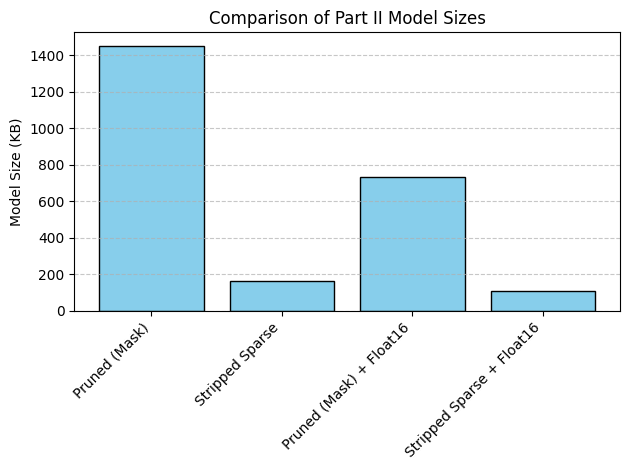

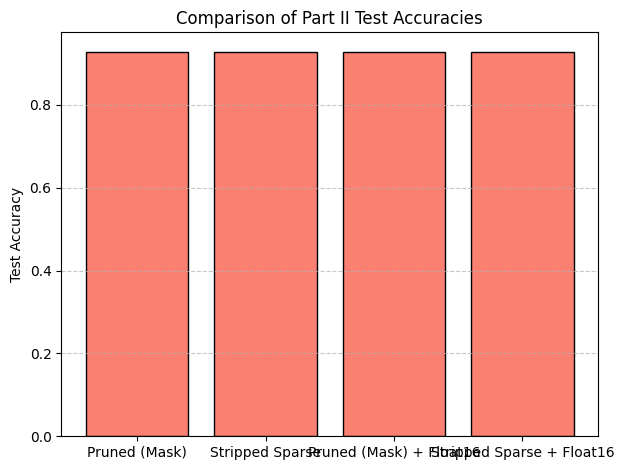

In [17]:
# TODO:
# Plot:
# 1. a bar chart of Part II model sizes
# 2. a bar chart of Part II test accuracies

# <-- Enter your code here <--#
models = ["Pruned (Mask)", "Stripped Sparse", "Pruned (Mask) + Float16", "Stripped Sparse + Float16"]
accuracies = [acc_pruned, acc_sparse, acc_pruned_f16, acc_sparse_f16]
sizes = [size_pruned_kb, size_sparse_kb, size_pruned_f16_kb, size_sparse_f16_kb]

plt.bar(models, sizes, color='skyblue', edgecolor='black')
plt.ylabel('Model Size (KB)')
plt.title('Comparison of Part II Model Sizes')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.bar(models, accuracies, color='salmon', edgecolor='black')
plt.ylabel('Test Accuracy')
plt.title('Comparison of Part II Test Accuracies')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Confusion Matrix for the Stripped Sparse + Float16 Model

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Classification Report (Stripped Sparse + Float16):
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       496
           1       0.94      0.90      0.92       471
           2       0.94      0.92      0.93       420
           3       0.93      0.89      0.91       491
           4       0.87      0.94      0.90       532
           5       1.00      0.96      0.98       537

    accuracy                           0.93      2947
   macro avg       0.93      0.93      0.93      2947
weighted avg       0.93      0.93      0.93      2947



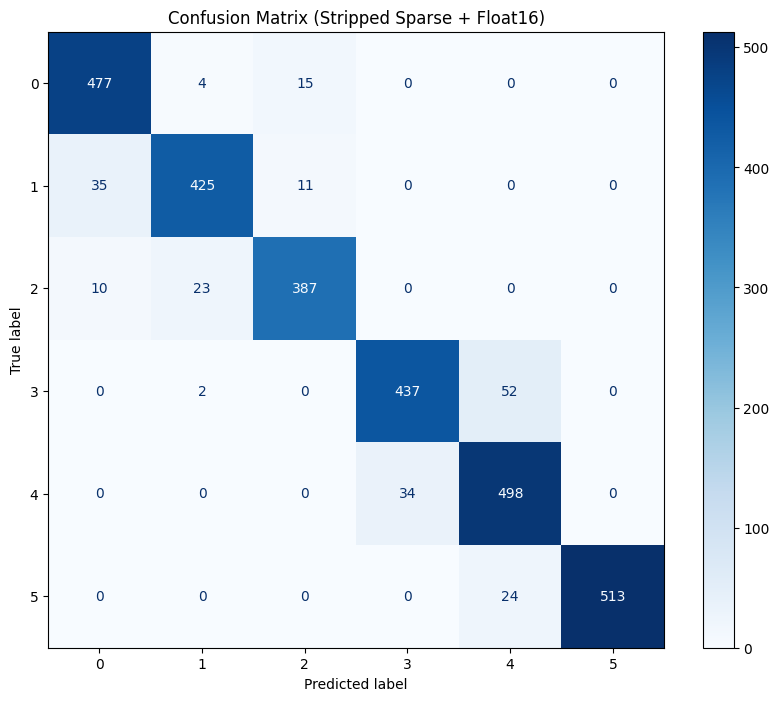

In [18]:
# TODO:
# Plot the confusion matrix for the stripped sparse + float16 TFLite model.
# Print the classification report for the stripped sparse + float16 TFLite model.

# <-- Enter your code here <--#
_, y_pred_sparse_f16 = evaluate_tflite_model(tflite_sparse_model, X_test, y_test)

print("Classification Report (Stripped Sparse + Float16):")
print(classification_report(y_test, y_pred_sparse_f16))

cm = confusion_matrix(y_test, y_pred_sparse_f16)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix (Stripped Sparse + Float16)")
plt.show()

## 13. Summary Questions

Write short answers to the following:
1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached?

No. Pruning alone increases the file size when wrappers are attached because the TFLite model must store the original weights along with the pruning masks.

2. Why does `strip_pruning(...)` matter before export?

It removes the pruning wrapper layers and does sparsity by turning masked weights into actual zeros. This allows the TFLite converter to store the model more efficiently, since it doesn't need the wrapper metadata.

3. Which model had the smallest file size in this notebook?

The Stripped Sparse + Float16 model. It benefits from both structural sparsity  and half-precision quantization, which reduces the precision and the size of the remaining active weights.

4. Did float16 quantization noticeably change the test accuracy?

No. In this dataset, float16 quantization typically causes negligible degradation in test accuracy. It is a highly effective post-training optimization that maintains the model's predictive performance while significantly reducing its memory footprint.

5. If you were deploying this model on a resource-constrained device, which version would you choose and why?

I would choose the Stripped Sparse + Float16 version. It offers the best balance for a resource-constrained device by providing the smallest possible file size  while maintaining near-baseline accuracy, ensuring the model remains both performant and efficient.

## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- output cells or screenshots showing the comparison tables,
- confusion matrices for the baseline model and your final highlighted compressed model,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors using the **`Python (tinyml-arduino)`** kernel.


AI was used in all 3 notebooks to assist with debugging and searching up functions and answering questions.